# LSA for FMG-FMG Model

In this notebook, the derivative-based Local Sensitivity Analysis (LSA) for the FMG-FMG model is performed.

In [1]:
import json
import numpy as np

import sys
import os
sys.path.append(os.path.abspath("../.."))
from scripts.LSA.fmg_lsa_utils import (
    generate_derivatives,
    load_parameter_bounds,
    run_monte_carlo,
    save_statistics_npz
)

from scripts.LSA.fmg_lsa_vis_utils import (
    plot_local_sensitivity_indices,
    read_excel_range,
    plot_L1_grouped
)

### Perform LSA
In this code block, derivative-based sensitivity analysis is performed given the sample's specification in the config file. Step-by-step, sensitivity indices as functions are generated, in addition to each parameter range, followed by calculating the sensitivity indices calculated based on the sampled model parameters from the constructed ranges. Finally, the calculated indices are saved.

In [5]:
# Load configuration for the specified HSWF content and GnP
HS = 20
GnP_idx = 3
with open(f'../../configs/LSA/{HS}HSWF_FMG_Config.json', 'r') as config_file:
    config = json.load(config_file)

file_path = config['file_path']
rows = config['rows']
cols = config['cols']
params_list = config['params_list']
GnP_list = config['GnP_list']

# Define frequency range for analysis
w_freq = np.logspace(-8, 2, 500)

# Generate funciton for derivative based sensitivity analyis
funcs_dEp, funcs_dEpp = generate_derivatives()

# Load parameter bounds for Monte Carlo sampling
param_bounds = load_parameter_bounds(file_path, rows, cols, gnp_index=GnP_idx, std_fctr=0.05)

# Run Monte Carlo sampling and compute sensitivity indices
results = run_monte_carlo(
    funcs_dEp, 
    funcs_dEpp, 
    param_bounds, 
    params_list, 
    w_freq, 
    n_mc=100_000, 
    batch_size=50_000
)

# Save indices results to .npz file
save_statistics_npz(results, params_list, w_freq, HS, GnP_list[GnP_idx], file_path)

Derivative functions generated successfully.
Parameter bounds calculated successfully.
Starting Monte Carlo simulation with 100000 iterations...
Completed 50000 / 100000 iterations
Completed 100000 / 100000 iterations
Monte Carlo simulation completed successfully.
Statistics saved successfully to ../../results/LSA/20HSWF_FMG/20HS_1.5GnP.npz


### Visualization

The following code cell use `plot_local_sensitivity_indices` to reproduce Fig. 7 and Figures S4 and S5 in the paper, depicting the variation of normalized local sensitivity indices.

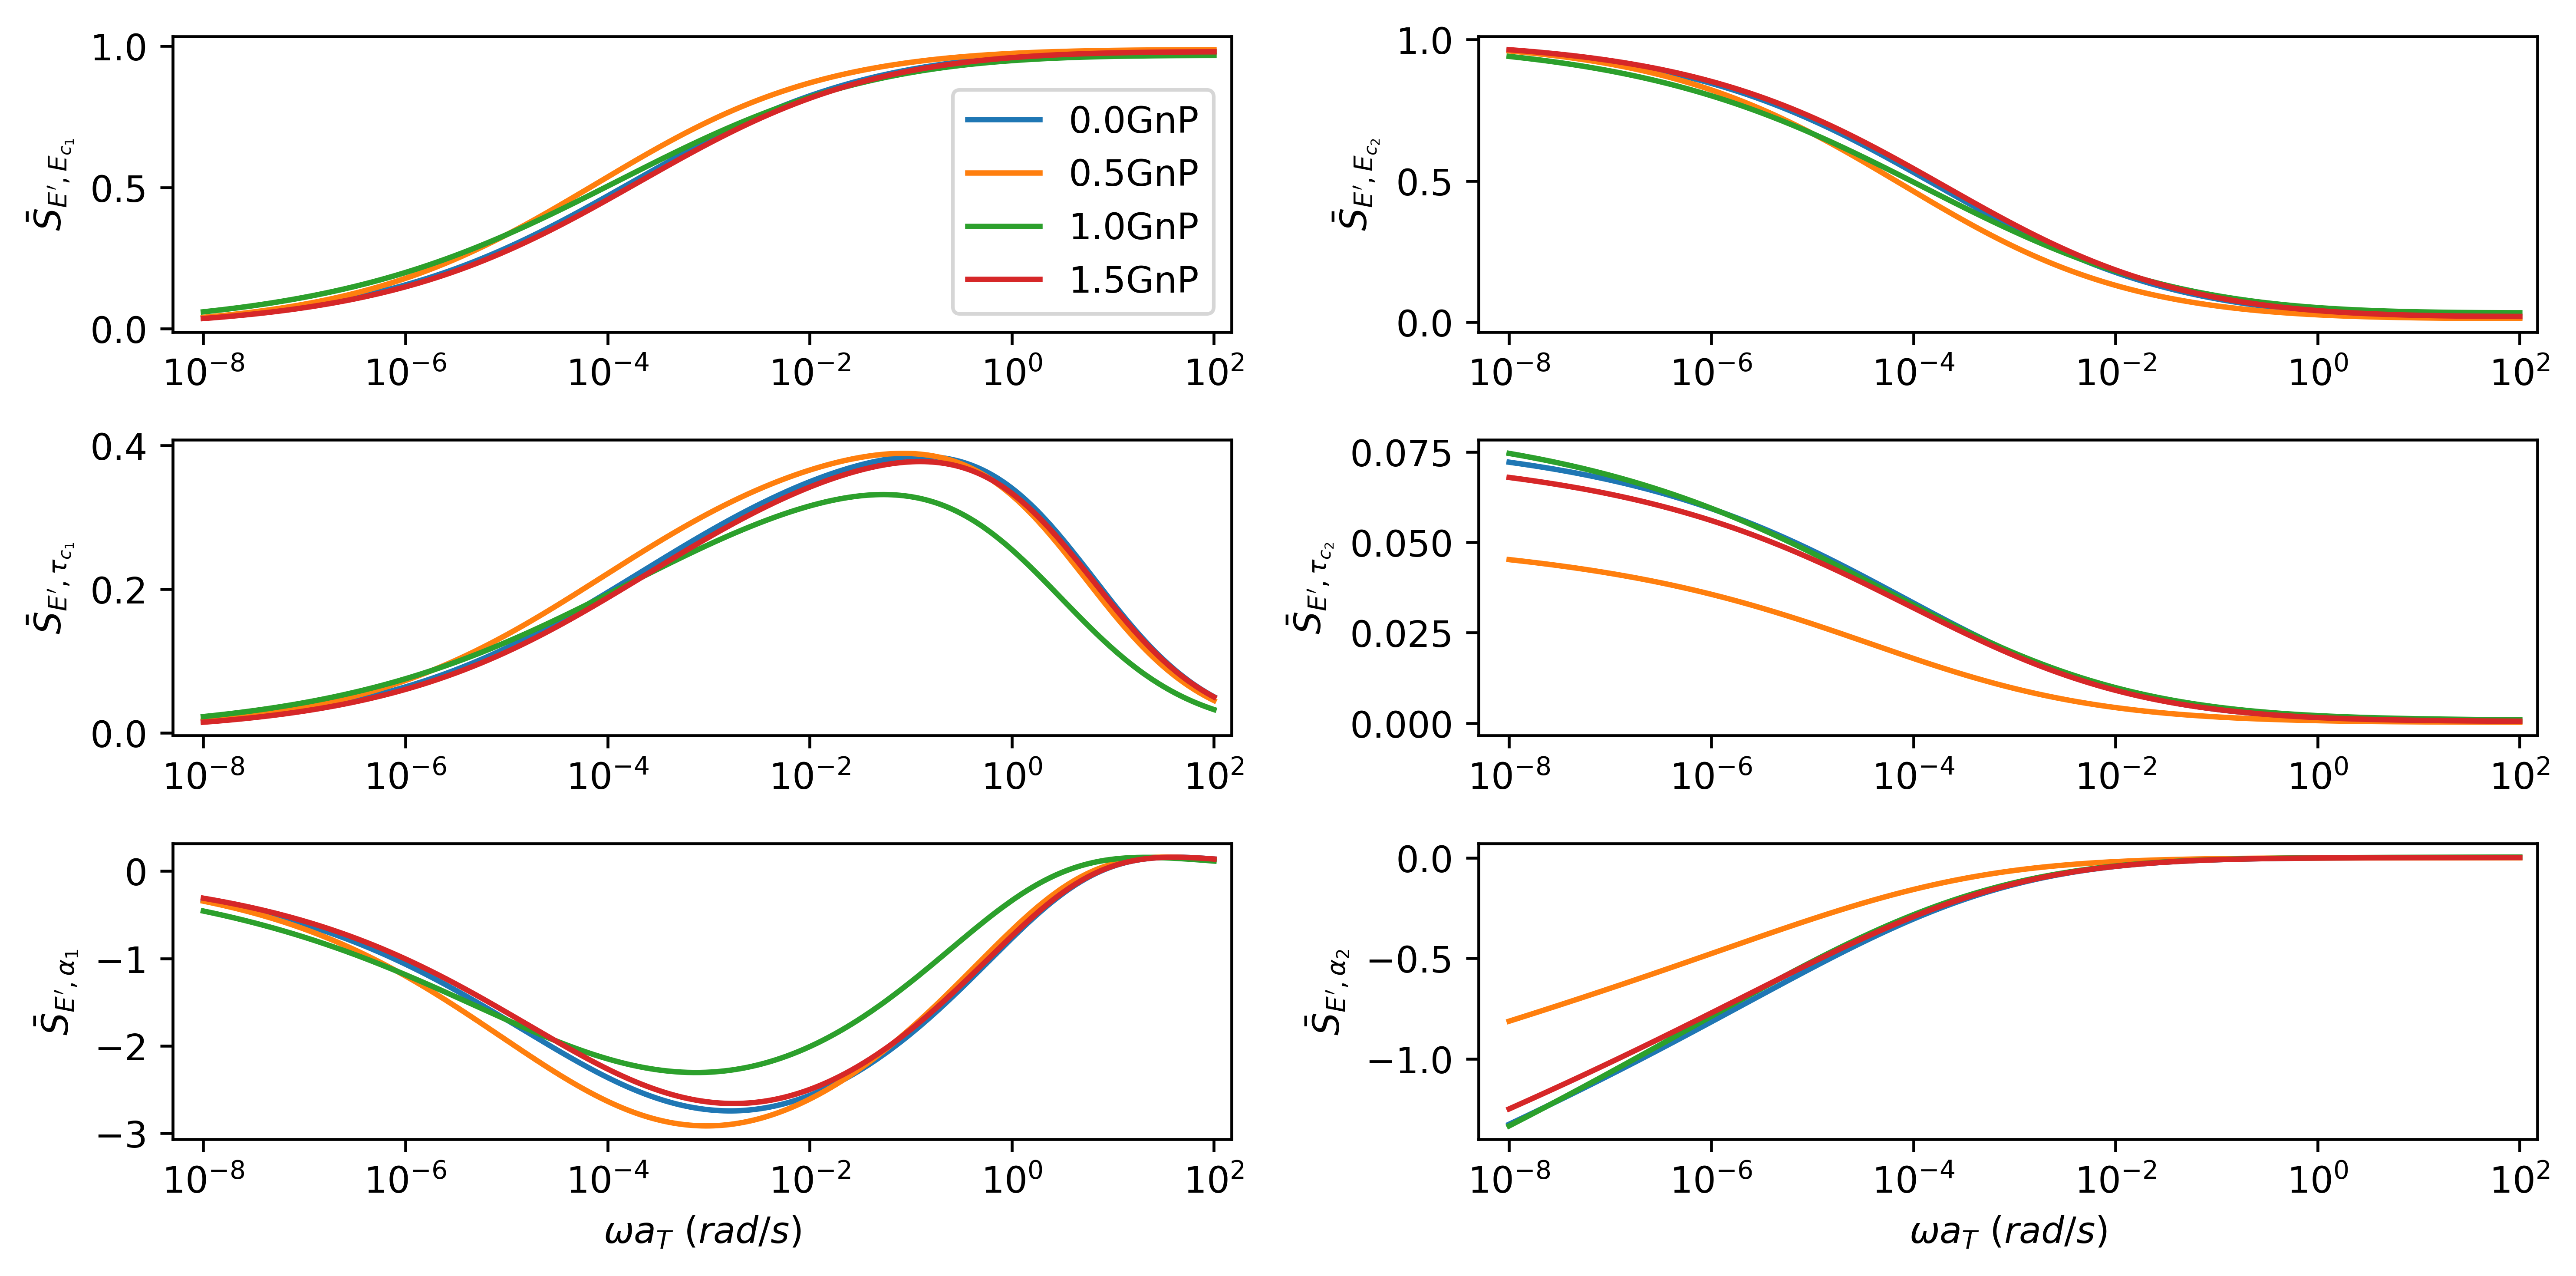

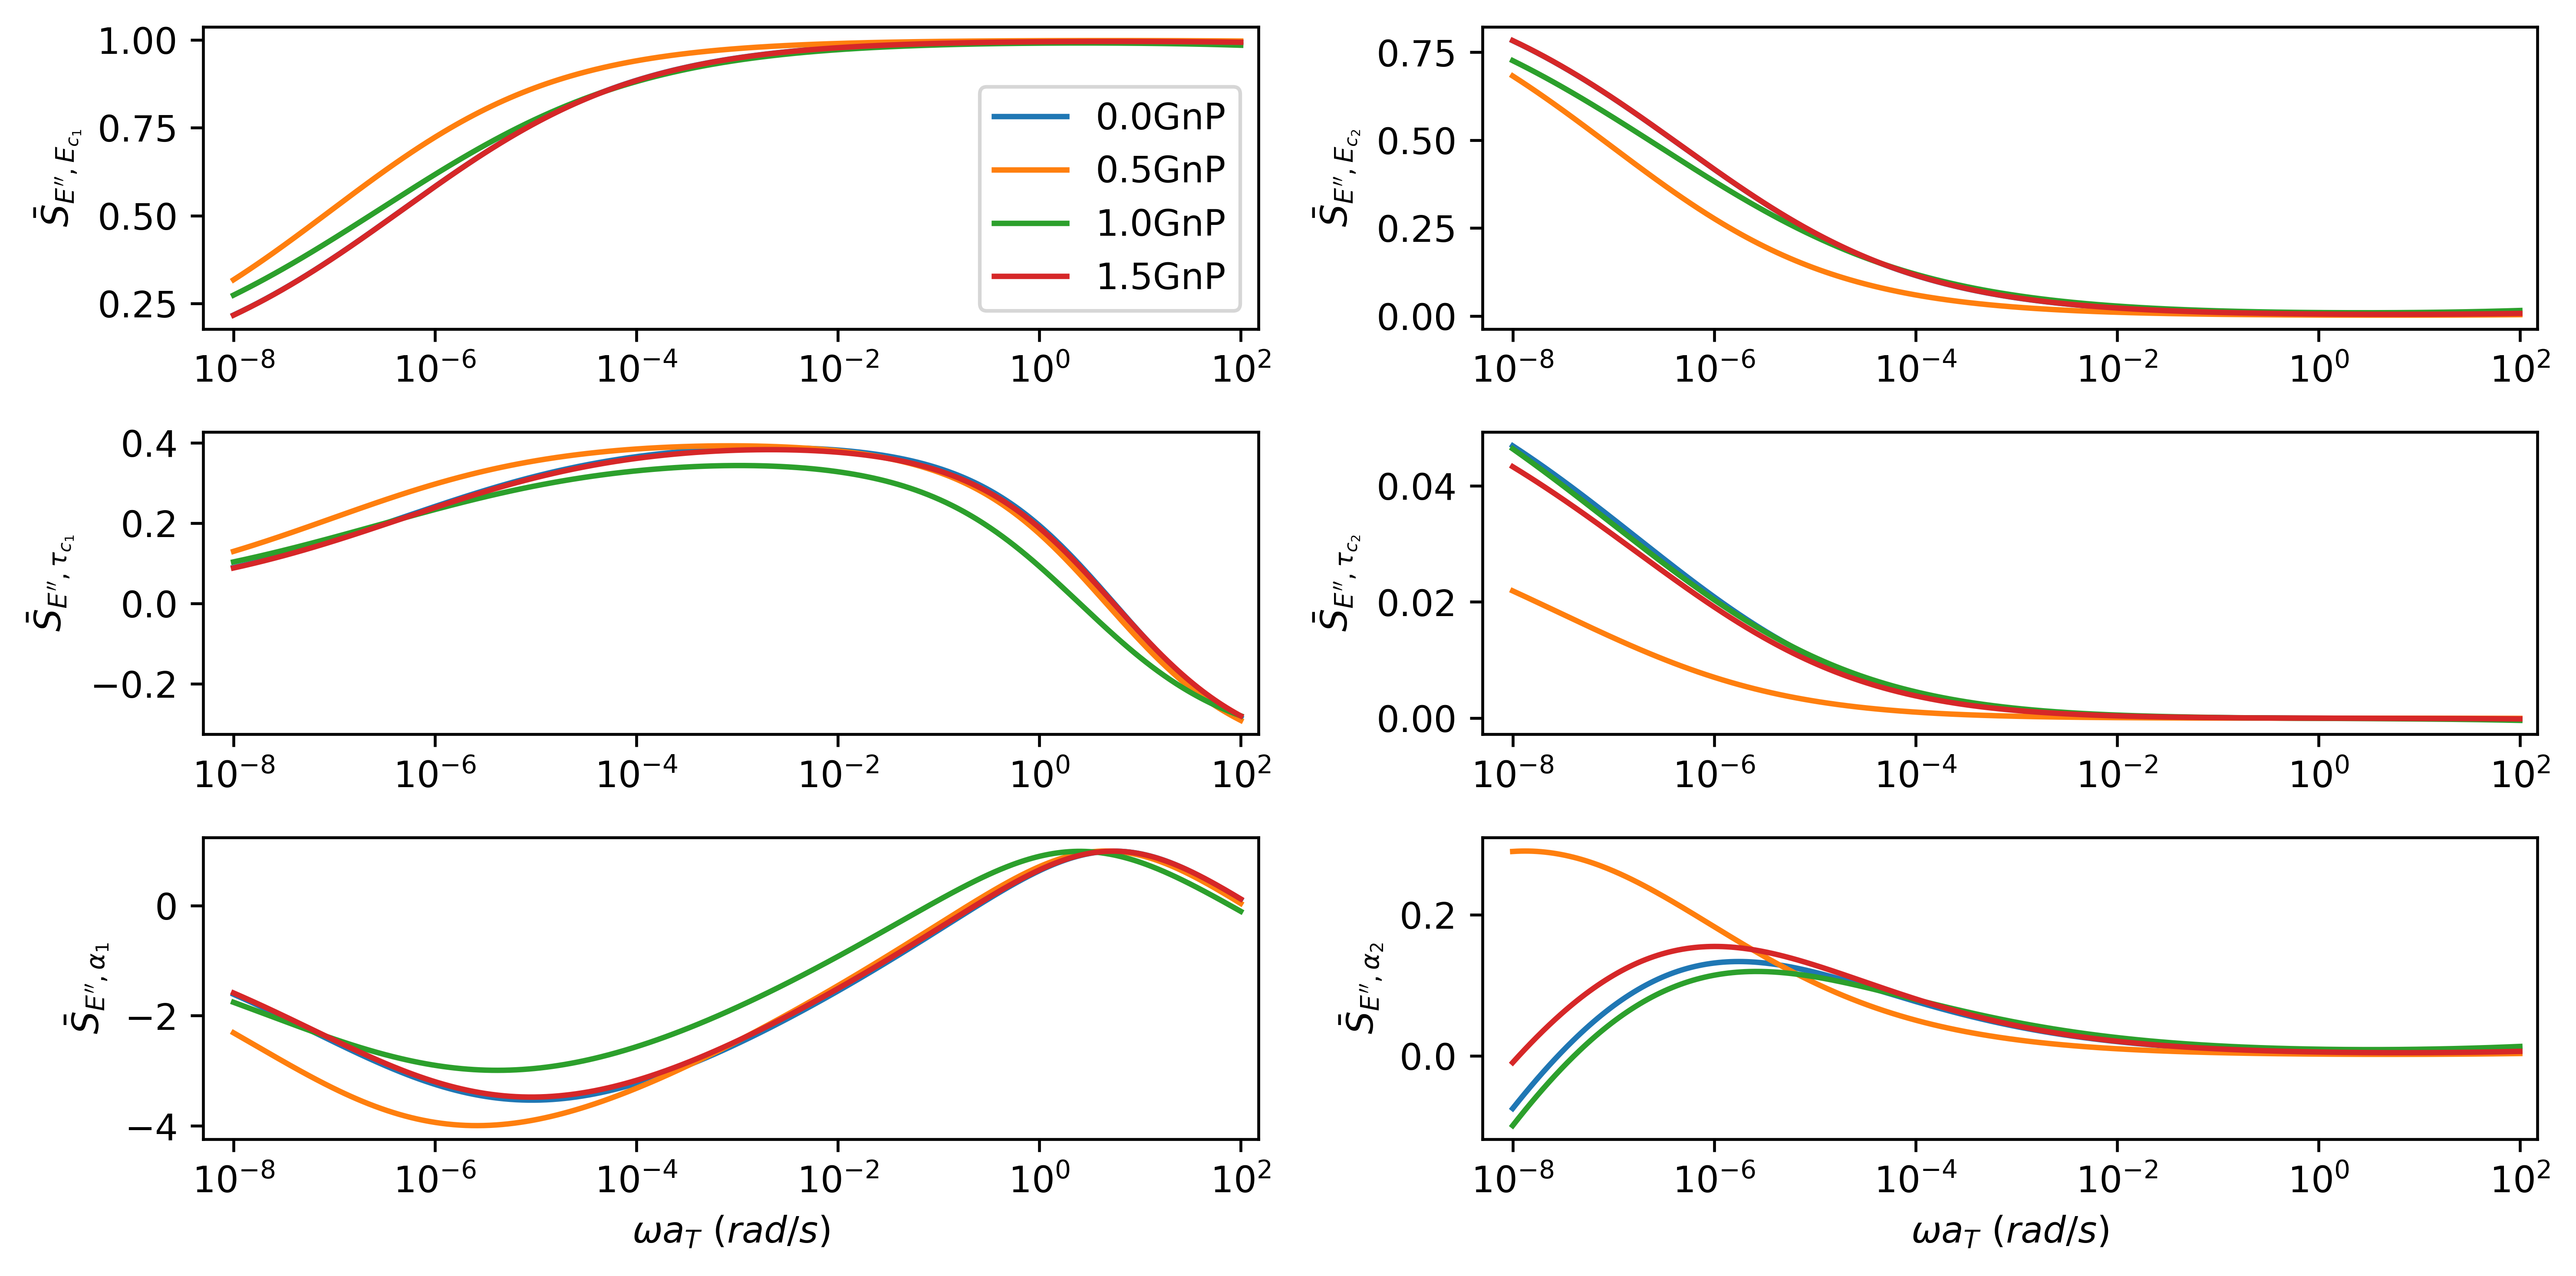

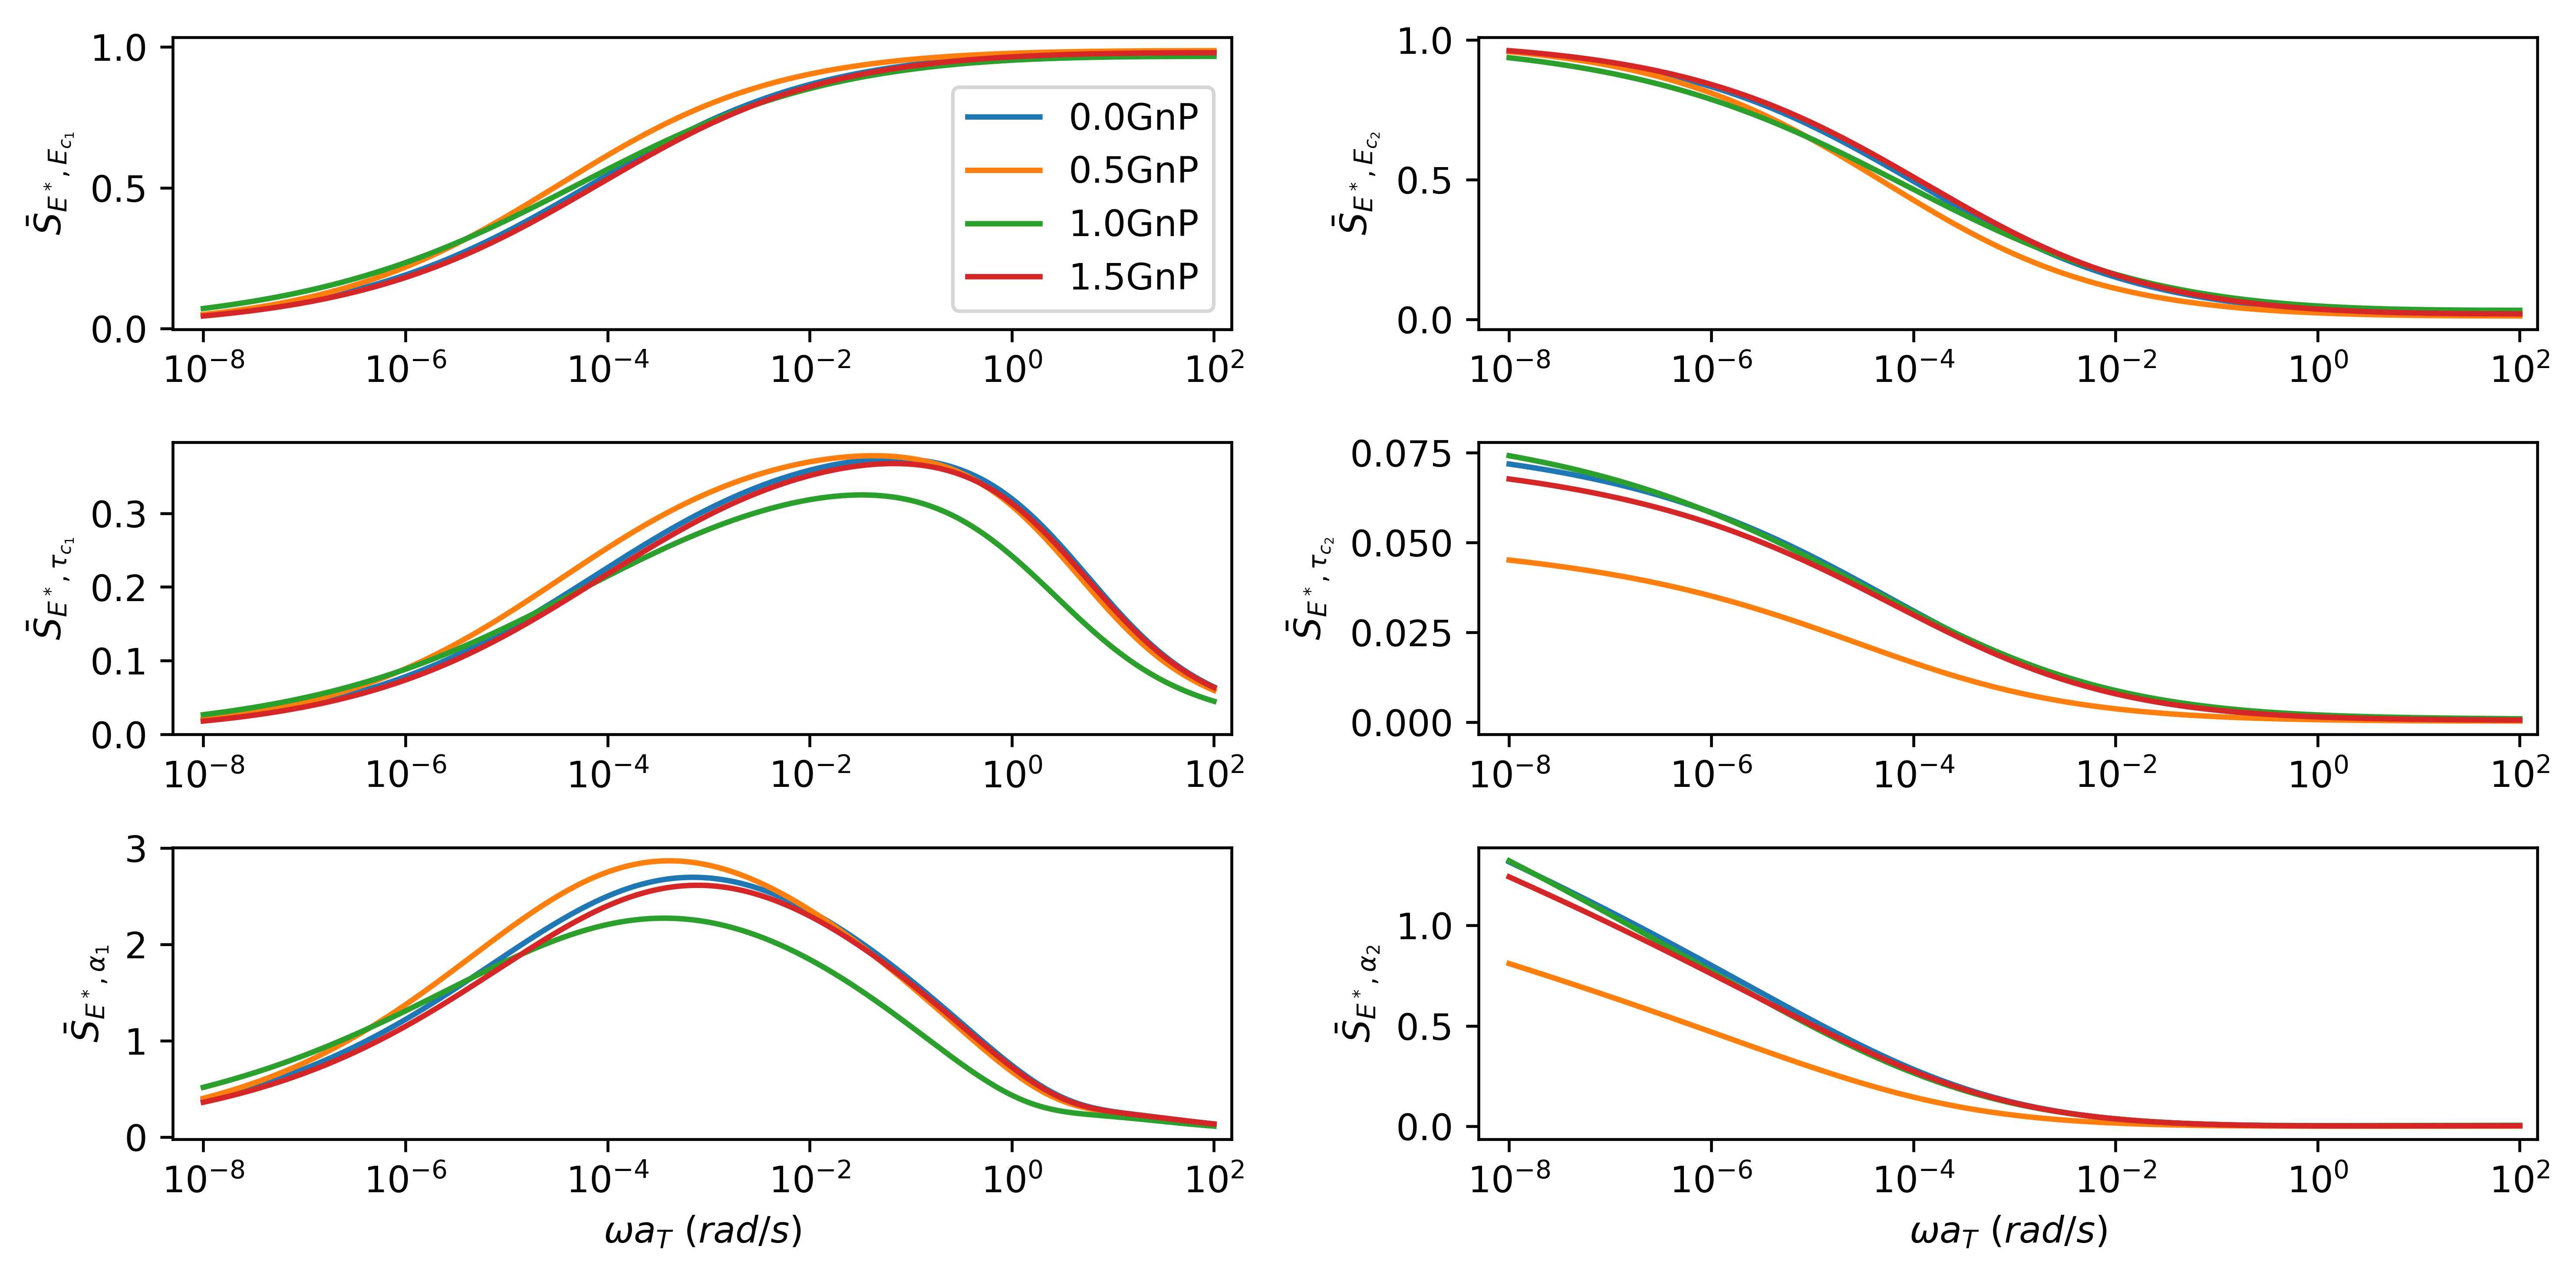

In [10]:
HS = 20
with open(f'../../configs/LSA/{HS}HSWF_FMG_Config.json', 'r') as config_file:
    config = json.load(config_file)

file_path = config['file_path']
rows = config['rows']
cols = config['cols']
params_list = config['params_list']
GnP_list = config['GnP_list']

plot_local_sensitivity_indices('Ep', HS, GnP_list, file_path)
plot_local_sensitivity_indices('Epp', HS, GnP_list, file_path)
plot_local_sensitivity_indices('Ecomplex', HS, GnP_list, file_path)

### Barplot of $L_1$ of Local Sensitivity Indices
The following code cell use `plot_L1_grouped` to reproduce Fig. 7 in the paper. Mean and std of $L_1$ of sensitivity indices are already calculated and stored in `LSA_FMG.xlsx`. For each modulus, you might want to change `ylabel` and `save_path` of `plot_L1_grouped` accordingly.

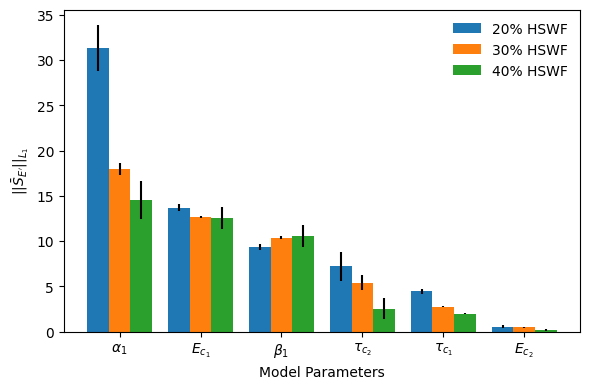

In [7]:
filename = "../../results/LSA/LSA_FMG.xlsx"

Linf_Ep_20HS  = read_excel_range(filename=filename, cell_range="C8:H9")
Linf_Ep_30HS  = read_excel_range(filename=filename, cell_range="C15:H16")
Linf_Ep_40HS  = read_excel_range(filename=filename, cell_range="C22:H23")

Linf_Epp_20HS = read_excel_range(filename=filename, cell_range="L8:Q9")
Linf_Epp_30HS = read_excel_range(filename=filename, cell_range="L15:Q16")
Linf_Epp_40HS = read_excel_range(filename=filename, cell_range="L22:Q23")

Linf_Ecomplex_20HS = read_excel_range(filename=filename, cell_range="U8:Z9")
Linf_Ecomplex_30HS = read_excel_range(filename=filename, cell_range="U15:Z16")
Linf_Ecomplex_40HS = read_excel_range(filename=filename, cell_range="U22:Z23")

Linf_Ep_mean = np.vstack([Linf_Ep_20HS[0, :],  Linf_Ep_30HS[0, :],  Linf_Ep_40HS[0, :]])
Linf_Ep_std = np.vstack([Linf_Ep_20HS[1, :],  Linf_Ep_30HS[1, :],  Linf_Ep_40HS[1, :]])

Linf_Epp_mean = np.vstack([Linf_Epp_20HS[0, :], Linf_Epp_30HS[0, :], Linf_Epp_40HS[0, :]])
Linf_Epp_std = np.vstack([Linf_Epp_20HS[1, :], Linf_Epp_30HS[1, :], Linf_Epp_40HS[1, :]])

Linf_Ecomplex_mean = np.vstack([Linf_Ecomplex_20HS[0, :], Linf_Ecomplex_30HS[0, :], Linf_Ecomplex_40HS[0, :]])
Linf_Ecomplex_std = np.vstack([Linf_Ecomplex_20HS[1, :], Linf_Ecomplex_30HS[1, :], Linf_Ecomplex_40HS[1, :]])

plot_L1_grouped(
    Linf_Ep_mean,
    Linf_Ep_std,
    ylabel=r"$||\bar{S}_{E^{\prime}}||_{L_{1}}$",  # E^{\prime} or E^{\prime\prime} or |E^{*}|
    save_path="../../results/LSA/LSA_L1_Ep_FMG"  # Ep or Epp or Ecomplex
)